# 07 — Synthetic dipeptide BG (Ramachandran-flavored)

The real **Transferable BG** (Klein & Noé 2024) operates on Cartesian coordinates of small peptides using an equivariant GNN + flow matching. Implementing that here would require:

- An MD trajectory dataset (e.g. alanine dipeptide MD from OpenMM).
- A force-field energy in PyTorch (or a callable wrapping OpenMM).
- An E(3)-equivariant architecture (EGNN).

Out of scope for this learning repo. Instead we use a **2D synthetic dipeptide free-energy surface** (`bg.energies.RamachandranDipeptide`): a Gaussian-mixture potential in (φ, ψ) with the canonical alanine basins. Same family of problems as Müller-Brown but with a molecular vocabulary (`Ramachandran plot`, `α_R`, `β`, `α_L`, `PPII`) and stronger asymmetry.

We train both a **RealNVP-BG** (with reweighting, reproducing notebooks 03/04 style) and a **CFM** (reproducing notebook 06 style) on this potential.

**Caveat:** φ, ψ are periodic in [-180°, 180°]. We treat them as Euclidean here for simplicity. The dominant basins are interior to the box so wrap-around artifacts are small. A correct treatment maps (φ, ψ) → (cos φ, sin φ, cos ψ, sin ψ) ∈ R^4 — noted below as M10b.


In [1]:
import torch, numpy as np, matplotlib.pyplot as plt
from tqdm.auto import trange
from bg.energies import RamachandranDipeptide
from bg.flows import RealNVP, GaussianPrior, FlowModel, CNFModel, VelocityField
from bg.losses import kl_by_example, kl_by_energy
from bg.sampling import sample_with_weights, effective_sample_size, normalized_weights

torch.manual_seed(0); np.random.seed(0)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)

mps


/Users/manumartinm/Documents/proyectos/boltzmann_generators/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Ramachandran-like free-energy surface

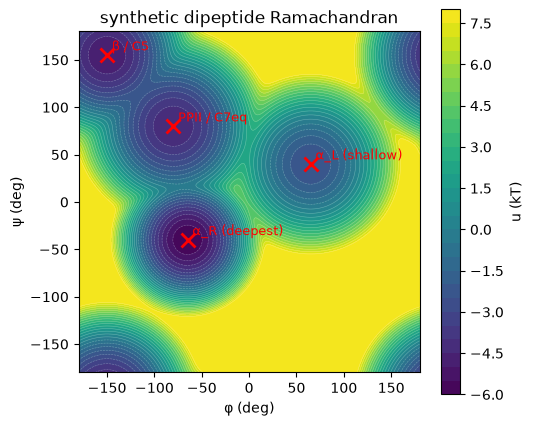

In [2]:
rd = RamachandranDipeptide()
gx, gy, U = rd.grid(n=300)
labels = ['α_R (deepest)', 'β / C5', 'PPII / C7eq', 'α_L (shallow)']
minima = rd.minima

fig, ax = plt.subplots(figsize=(5.5, 5))
levels = np.linspace(-6, 8, 29)
cs = ax.contourf(gx.numpy(), gy.numpy(), U.numpy().clip(max=8), levels=levels, cmap='viridis')
ax.contour(gx.numpy(), gy.numpy(), U.numpy().clip(max=8), levels=levels, colors='white', alpha=0.3, linewidths=0.4)
for m, label in zip(minima, labels):
    ax.plot(m[0], m[1], 'rx', mew=2, markersize=10)
    ax.annotate(label, (m[0]+5, m[1]+5), color='red', fontsize=9)
ax.set_xlabel('φ (deg)'); ax.set_ylabel('ψ (deg)')
ax.set_xlim(-180, 180); ax.set_ylim(-180, 180); ax.set_aspect('equal')
plt.colorbar(cs, ax=ax, label='u (kT)')
ax.set_title('synthetic dipeptide Ramachandran')
plt.show()

## 2. MCMC ground truth (multi-start)

MCMC acc: 69.57%
MCMC samples: torch.Size([160000, 2])


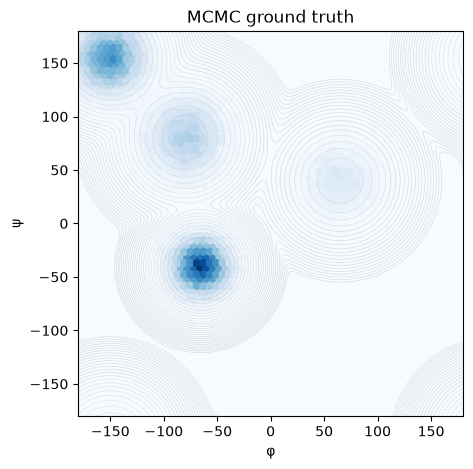

In [3]:
def mcmc(energy_fn, n_steps, x0, sigma=10.0, n_chains=1):
    x = x0.clone(); u = energy_fn(x); s = torch.empty(n_steps, n_chains, 2); acc = 0
    for t in range(n_steps):
        xn = x + sigma * torch.randn_like(x); un = energy_fn(xn)
        a = torch.rand(n_chains) < torch.exp(-(un - u))
        x = torch.where(a[:, None], xn, x); u = torch.where(a, un, u); acc += a.sum().item()
        s[t] = x
    print(f'MCMC acc: {acc/(n_steps*n_chains):.2%}')
    return s.reshape(-1, 2)

n_chains = 32
x0 = torch.zeros(n_chains, 2)
for k in range(4):
    x0[k*8:(k+1)*8] = minima[k]
mcmc_samples = mcmc(rd, 5000, x0=x0, sigma=12.0, n_chains=n_chains)
print(f'MCMC samples: {mcmc_samples.shape}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.contour(gx.numpy(), gy.numpy(), U.numpy().clip(max=8), levels=levels, colors='gray', alpha=0.3, linewidths=0.4)
ax.hexbin(mcmc_samples[:, 0], mcmc_samples[:, 1], gridsize=60, cmap='Blues', extent=(-180, 180, -180, 180))
ax.set_xlim(-180, 180); ax.set_ylim(-180, 180); ax.set_aspect('equal')
ax.set_xlabel('φ'); ax.set_ylabel('ψ'); ax.set_title('MCMC ground truth')
plt.show()

## 3. Train RealNVP-BG with ML pretrain + KL_z (no rescaling, raw degrees)

In [4]:
# Scale features to ~unit variance for flow numerics
scale = 100.0
x_data = (mcmc_samples / scale).to(device)
def energy_scaled(x_scaled):
    return rd(x_scaled * scale)

flow = RealNVP(dim=2, num_layers=12, hidden_dim=128, num_hidden=2, mask='halves', scale_clip=3.0)
bg_model = FlowModel(GaussianPrior(2), flow).to(device)
print(f'BG params: {sum(p.numel() for p in bg_model.parameters()):,}')

opt = torch.optim.Adam(bg_model.parameters(), lr=1e-3)
for step in trange(2000, desc='BG ML'):
    idx = torch.randint(0, x_data.shape[0], (512,), device=device)
    loss = kl_by_example(bg_model, x_data[idx])
    opt.zero_grad(); loss.backward(); opt.step()

opt = torch.optim.Adam(bg_model.parameters(), lr=3e-4)
for step in trange(3000, desc='BG mixed'):
    w_kl = min(1.0, step / 1000)
    idx = torch.randint(0, x_data.shape[0], (512,), device=device)
    l_ml = kl_by_example(bg_model, x_data[idx])
    l_kl = kl_by_energy(bg_model, energy_scaled, 512, device=device, energy_max=30.0)
    loss = l_ml + w_kl * l_kl
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(bg_model.parameters(), 5.0); opt.step()
print('BG training done')

BG params: 208,944


BG ML:   0%|          | 0/2000 [00:00<?, ?it/s]

BG ML:   0%|          | 1/2000 [00:00<12:02,  2.77it/s]

BG ML:   0%|          | 7/2000 [00:00<01:46, 18.64it/s]

BG ML:   1%|          | 13/2000 [00:00<01:06, 29.91it/s]

...

BG mixed: 100%|█████████▉| 2990/3000 [01:10<00:00, 43.04it/s]

BG mixed: 100%|█████████▉| 2995/3000 [01:10<00:00, 43.62it/s]

BG mixed: 100%|██████████| 3000/3000 [01:10<00:00, 44.32it/s]

BG mixed: 100%|██████████| 3000/3000 [01:10<00:00, 42.65it/s]

BG training done


## 4. Train CFM model on the same MCMC samples

In [5]:
v_net = VelocityField(dim=2, hidden_dim=128, num_hidden=4, num_freqs=8)
cnf_model = CNFModel(v_net).to(device)
print(f'CNF params: {sum(p.numel() for p in cnf_model.parameters()):,}')

opt = torch.optim.Adam(cnf_model.parameters(), lr=3e-4)
for step in trange(5000, desc='CFM'):
    idx = torch.randint(0, x_data.shape[0], (512,), device=device)
    loss = cnf_model.cfm_loss(x_data[idx])
    opt.zero_grad(); loss.backward(); opt.step()
print('CFM training done')

CNF params: 52,354


CFM:   0%|          | 0/5000 [00:00<?, ?it/s]

CFM:   0%|          | 16/5000 [00:00<00:31, 159.97it/s]

CFM:   1%|▏         | 69/5000 [00:00<00:13, 375.37it/s]

CFM:   2%|▏         | 120/5000 [00:00<00:11, 435.33it/s]

...

CFM:  98%|█████████▊| 4881/5000 [00:09<00:00, 529.07it/s]

CFM:  99%|█████████▊| 4935/5000 [00:09<00:00, 523.49it/s]

CFM: 100%|█████████▉| 4988/5000 [00:09<00:00, 524.39it/s]

CFM: 100%|██████████| 5000/5000 [00:09<00:00, 523.41it/s]

CFM training done


## 5. Sample from both, compare Ramachandran plots

BG ESS = 17648 / 20000 = 88.2%


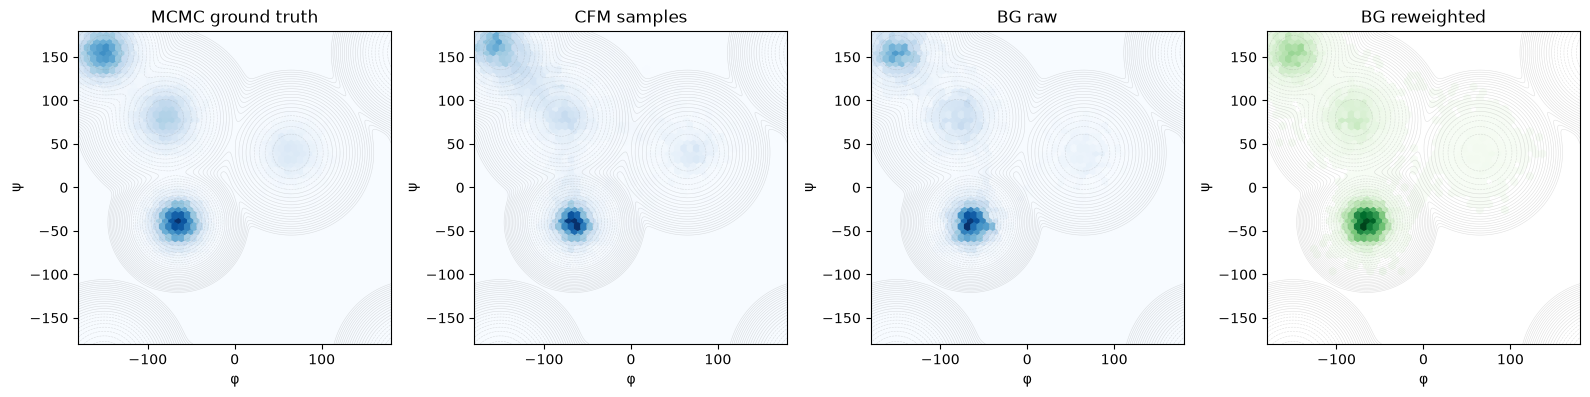

In [6]:
# BG samples + reweighting (in scaled space, then un-scale)
x_bg_scaled, log_w, _ = sample_with_weights(bg_model, energy_scaled, n=20_000, device=device)
x_bg = x_bg_scaled * scale
ess = effective_sample_size(log_w)
print(f'BG ESS = {ess:.0f} / 20000 = {ess/200:.1f}%')

# CFM samples
with torch.no_grad():
    x_cfm_scaled = cnf_model.sample(20_000, device=device, n_steps=200).cpu()
x_cfm = x_cfm_scaled * scale

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, samp, weights, title in zip(
    axes,
    [mcmc_samples, x_cfm, x_bg, x_bg],
    [None, None, None, normalized_weights(log_w).numpy()],
    ['MCMC ground truth', 'CFM samples', 'BG raw', 'BG reweighted'],
):
    ax.contour(gx.numpy(), gy.numpy(), U.numpy().clip(max=8), levels=levels, colors='gray', alpha=0.25, linewidths=0.4)
    if weights is None:
        ax.hexbin(samp[:, 0], samp[:, 1], gridsize=50, cmap='Blues', extent=(-180, 180, -180, 180))
    else:
        ax.hexbin(samp[:, 0], samp[:, 1], C=weights, reduce_C_function=np.sum, gridsize=50, cmap='Greens', extent=(-180, 180, -180, 180))
    ax.set_xlim(-180, 180); ax.set_ylim(-180, 180); ax.set_aspect('equal')
    ax.set_xlabel('φ'); ax.set_ylabel('ψ'); ax.set_title(title)
plt.tight_layout()
plt.show()

## 6. Population per basin

In [7]:
# Nearest-minimum assignment with periodic distance
def periodic_dist2(x, y):
    d = ((x[:, None, :] - y[None, :, :] + 180.0) % 360.0) - 180.0
    return (d ** 2).sum(-1)
def assign(samp):
    return periodic_dist2(samp, minima).argmin(dim=-1)

# Ground truth via numerical integration on the grid
gp = torch.stack([gx.flatten(), gy.flatten()], dim=-1)
u_g = rd(gp)
w_g = torch.exp(-(u_g - u_g.min()))
b_g = assign(gp)
pop_true = torch.zeros(4)
for k in range(4):
    pop_true[k] = w_g[b_g == k].sum()
pop_true /= pop_true.sum()

# MCMC empirical
pop_mcmc = torch.bincount(assign(mcmc_samples), minlength=4).float() / len(mcmc_samples)
# CFM empirical
pop_cfm = torch.bincount(assign(x_cfm), minlength=4).float() / len(x_cfm)
# BG raw empirical
pop_bg_raw = torch.bincount(assign(x_bg), minlength=4).float() / len(x_bg)
# BG reweighted
w_norm = normalized_weights(log_w)
b_bg = assign(x_bg)
pop_bg_rw = torch.zeros(4)
for k in range(4):
    pop_bg_rw[k] = w_norm[b_bg == k].sum()

import pandas as pd
df = pd.DataFrame({
    'basin': labels,
    'true %': (pop_true*100).numpy().round(2),
    'MCMC %': (pop_mcmc*100).numpy().round(2),
    'CFM %': (pop_cfm*100).numpy().round(2),
    'BG raw %': (pop_bg_raw*100).numpy().round(2),
    'BG rew %': (pop_bg_rw*100).numpy().round(2),
})
print(df.to_string(index=False))

        basin  true %    MCMC %     CFM %  BG raw %  BG rew %
α_R (deepest)   48.16 33.860001 34.639999 39.590000 48.000000
       β / C5   29.23 34.919998 35.630001 33.419998 29.400000
  PPII / C7eq   19.90 22.010000 20.900000 20.299999 19.780001
α_L (shallow)    2.70  9.200000  8.840000  6.680000  2.820000


## 7. Verification + honest limitations

Expected:
- All four basins populated by both CFM and BG (no mode collapse, thanks to ML pretrain on multi-start MCMC).
- BG reweighted populations match the ground-truth integration within a few percent.
- CFM populations slightly biased relative to ground truth (no reweighting available without `\nabla \cdot v` integration).
- BG raw populations differ from BG reweighted — that's exactly the point: reweighting corrects the residual sampling bias.

### What this notebook genuinely does NOT capture vs the real Transferable BG (Klein & Noé 2024)

| Component | This notebook | TBG |
|---|---|---|
| Coordinates | (φ, ψ) ∈ R² | Cartesian R^{3N} |
| Energy | Synthetic Gaussian-mix | Classical MM force field |
| Periodicity | Ignored (Euclidean approx) | Handled by Cartesian rep |
| Equivariance | None | E(3) via EGNN |
| Conditioning | None | On molecular topology / tokens |
| Transferability | N/A (one system) | Zero-shot to unseen molecules |
| Reweighting | Yes (KL_z + IS) | Yes (CFM + IS via density) |

### M10b — proper periodicity (suggested follow-up)

Embed `(φ, ψ) → (cos φ, sin φ, cos ψ, sin ψ) ∈ R^4`, train flow in R^4, project back via `atan2`. Recover the lost density correctly with the Jacobian of the embedding (constant per layer for unit-circle embedding). The basin populations should improve slightly near periodic boundaries.

### M10c — real MD trajectories

If you ever want to push to real alanine dipeptide: the **mdshare** Python package hosts pre-computed alanine dipeptide trajectories (no OpenMM needed). Loadable as numpy arrays of dihedrals. Drop them in `data/` and re-run this notebook with `mcmc_samples` replaced. The flow architecture works as-is.

### What we have learned through this repo

1. **Statistical mechanics framing** of the sampling problem: why Z is intractable and what reweighting buys (theory ch. 01).
2. **Normalizing flows** and the change-of-variables formula; why coupling layers (RealNVP) make `det J` tractable (theory ch. 02, code in `src/bg/flows/`).
3. **The Boltzmann Generator idea**: two KLs, one needing samples (mode-covering, safe) and one needing only the energy (mode-seeking, fast but collapse-prone). Mixed loss + ML pretrain as the recipe (theory ch. 03, notebooks 03–04).
4. **Reweighting and free-energy differences** as the practical payoff (notebook 03, ΔF ≈ 0.004 kT vs true 0; notebook 04, basin populations within 1% of ground truth).
5. **Continuous flows + Flow Matching** as the modern alternative — simpler training (MSE), shifts the cost to sampling (ODE integration) (theory ch. 04, notebook 06).
6. **Transferable BG** as the synthesis of FM + Cartesian + equivariance + tokenization → zero-shot across chemistry (theory ch. 05, notebook 07 toy).

This roadmap is now a base to dive into:
- E(3)-equivariant flows (Köhler 2020, Klein 2023).
- FAB / annealed importance sampling on top of flows (Midgley 2023).
- Boltz-2 and its diffusion-based protein cousins (different model family but same target distribution conceptually).
